In [141]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from rdkit import Chem
from rdkit.Chem import Draw

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, r2_score

## Loading, Preprocessing & Analyzing Bioconcentration Factor data 

In [2]:
bcf_data_path = Path.cwd() / "data" / "qspr_bcf_data.csv"

In [3]:
# Load the bioconcentration factor data
df_bcf = pd.read_csv(bcf_data_path)

In [4]:
df_bcf

,Unnamed: 0,CAS,SMILES,Experimental value [log(L/kg)],NumAromaticRings,NumHAcceptors,NumHeteroatoms,NumRotatableBonds,NumValenceElectrons,qed,TPSA,MolMR,BalabanJ,BertzCT,fr_COO,fr_COO2,fr_halogen,MolWt,MolLogP
0,0,50-29-3,c1cc(ccc1C(c2ccc(cc2)Cl)C(Cl)(Cl)Cl)Cl,3.605,2,0,5,2,100,0.540334,0.00,85.0370,2.474117,494.044161,0,0,5,354.491,6.49550
1,1,50-30-6,O=C(O)c1c(cccc1Cl)Cl,-0.222,1,1,4,1,58,0.740184,37.30,43.4213,3.318913,276.242090,1,1,2,191.013,2.69160
2,2,50-31-7,O=C(O)c1c(ccc(c1Cl)Cl)Cl,0.073,1,1,5,1,64,0.744344,37.30,48.4313,3.428931,335.668528,1,1,3,225.458,3.34500
3,3,50-32-8,c1ccc2c(c1)cc3ccc4cccc5ccc2c3c45,2.731,5,0,0,0,92,0.243454,0.00,87.6520,2.230840,1069.721887,0,0,0,252.316,5.73720
4,4,51-28-5,O=[N+]([O-])c1ccc(O)c(c1)[N+](=O)[O-],0.052,1,5,7,2,68,0.548520,106.51,41.4156,3.267052,375.287402,0,0,0,184.107,1.20860
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,795,374726-62-2,O=C(NCCc1ccc(OCC#C)c(OC)c1)C(OCC#C)c2ccc(cc2)Cl,1.681,2,4,6,10,150,0.608597,56.79,113.0137,1.980197,896.574346,0,0,1,411.885,3.41040
796,796,110235-47-7,C(#CC)c1nc(nc(c1)C)Nc2ccccc2,2.447,2,3,3,2,84,0.795366,37.81,69.0457,2.289333,565.011461,0,0,0,223.279,2.90002
797,797,15302-91-7,C[N+]1(C)(CCCCC1),0.301,0,0,1,0,48,0.415670,0.00,35.6934,2.327883,68.456011,0,0,0,114.212,1.24670
798,798,57837-19-1,O=C(OC)C(N(C(=O)COC)c1c(cccc1C)C)C,0.845,1,4,5,5,110,0.771792,55.84,76.7560,3.299967,478.396923,0,0,0,279.336,1.84434


In [5]:
df_bcf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Unnamed: 0                      800 non-null    int64  
 1   CAS                             800 non-null    object 
 2   SMILES                          800 non-null    object 
 3   Experimental value [log(L/kg)]  800 non-null    float64
 4   NumAromaticRings                800 non-null    int64  
 5   NumHAcceptors                   800 non-null    int64  
 6   NumHeteroatoms                  800 non-null    int64  
 7   NumRotatableBonds               800 non-null    int64  
 8   NumValenceElectrons             800 non-null    int64  
 9   qed                             800 non-null    float64
 10  TPSA                            800 non-null    float64
 11  MolMR                           800 non-null    float64
 12  BalabanJ                        800 

In [6]:
df_bcf.head()

,Unnamed: 0,CAS,SMILES,Experimental value [log(L/kg)],NumAromaticRings,NumHAcceptors,NumHeteroatoms,NumRotatableBonds,NumValenceElectrons,qed,TPSA,MolMR,BalabanJ,BertzCT,fr_COO,fr_COO2,fr_halogen,MolWt,MolLogP
0,0,50-29-3,c1cc(ccc1C(c2ccc(cc2)Cl)C(Cl)(Cl)Cl)Cl,3.605,2,0,5,2,100,0.540334,0.00,85.0370,2.474117,494.044161,0,0,5,354.491,6.4955
1,1,50-30-6,O=C(O)c1c(cccc1Cl)Cl,-0.222,1,1,4,1,58,0.740184,37.30,43.4213,3.318913,276.242090,1,1,2,191.013,2.6916
2,2,50-31-7,O=C(O)c1c(ccc(c1Cl)Cl)Cl,0.073,1,1,5,1,64,0.744344,37.30,48.4313,3.428931,335.668528,1,1,3,225.458,3.3450
3,3,50-32-8,c1ccc2c(c1)cc3ccc4cccc5ccc2c3c45,2.731,5,0,0,0,92,0.243454,0.00,87.6520,2.230840,1069.721887,0,0,0,252.316,5.7372
4,4,51-28-5,O=[N+]([O-])c1ccc(O)c(c1)[N+](=O)[O-],0.052,1,5,7,2,68,0.548520,106.51,41.4156,3.267052,375.287402,0,0,0,184.107,1.2086


In [16]:
X = df_bcf.drop(['Unnamed: 0', 'CAS', 'SMILES', 'Experimental value [log(L/kg)]'], axis=1)

In [17]:
X

,NumAromaticRings,NumHAcceptors,NumHeteroatoms,NumRotatableBonds,NumValenceElectrons,qed,TPSA,MolMR,BalabanJ,BertzCT,fr_COO,fr_COO2,fr_halogen,MolWt,MolLogP
0,2,0,5,2,100,0.540334,0.00,85.0370,2.474117,494.044161,0,0,5,354.491,6.49550
1,1,1,4,1,58,0.740184,37.30,43.4213,3.318913,276.242090,1,1,2,191.013,2.69160
2,1,1,5,1,64,0.744344,37.30,48.4313,3.428931,335.668528,1,1,3,225.458,3.34500
3,5,0,0,0,92,0.243454,0.00,87.6520,2.230840,1069.721887,0,0,0,252.316,5.73720
4,1,5,7,2,68,0.548520,106.51,41.4156,3.267052,375.287402,0,0,0,184.107,1.20860
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,2,4,6,10,150,0.608597,56.79,113.0137,1.980197,896.574346,0,0,1,411.885,3.41040
796,2,3,3,2,84,0.795366,37.81,69.0457,2.289333,565.011461,0,0,0,223.279,2.90002
797,0,0,1,0,48,0.415670,0.00,35.6934,2.327883,68.456011,0,0,0,114.212,1.24670
798,1,4,5,5,110,0.771792,55.84,76.7560,3.299967,478.396923,0,0,0,279.336,1.84434


## Correlation Matrix

In [18]:
corr_moldescr = X.corr()
corr_moldescr

,NumAromaticRings,NumHAcceptors,NumHeteroatoms,NumRotatableBonds,NumValenceElectrons,qed,TPSA,MolMR,BalabanJ,BertzCT,fr_COO,fr_COO2,fr_halogen,MolWt,MolLogP
NumAromaticRings,1.000000,0.244865,0.166836,-0.021990,0.427788,0.014030,0.248006,0.533404,-0.507535,0.778617,-0.074717,-0.074717,-0.056441,0.404220,0.369390
NumHAcceptors,0.244865,1.000000,0.746772,0.436545,0.639558,-0.093141,0.886244,0.523719,-0.176394,0.623913,0.013833,0.013833,-0.176536,0.517746,-0.097080
NumHeteroatoms,0.166836,0.746772,1.000000,0.319592,0.650353,-0.128586,0.725110,0.483794,0.073621,0.609972,0.081539,0.081539,0.480146,0.706135,0.124394
NumRotatableBonds,-0.021990,0.436545,0.319592,1.000000,0.691573,-0.335294,0.322972,0.646195,0.023556,0.284890,-0.034982,-0.034982,-0.097472,0.541754,0.434369
NumValenceElectrons,0.427788,0.639558,0.650353,0.691573,1.000000,-0.245782,0.553583,0.946903,-0.271089,0.818867,-0.033816,-0.033816,0.139622,0.887229,0.585051
qed,0.014030,-0.093141,-0.128586,-0.335294,-0.245782,1.000000,-0.095836,-0.250750,-0.064726,-0.150625,0.210498,0.210498,-0.060071,-0.255557,-0.277182
TPSA,0.248006,0.886244,0.725110,0.322972,0.553583,-0.095836,1.000000,0.414794,-0.110187,0.619814,0.180575,0.180575,-0.165199,0.436877,-0.197364
MolMR,0.533404,0.523719,0.483794,0.646195,0.946903,-0.250750,0.414794,1.000000,-0.390048,0.814098,-0.090249,-0.090249,0.051963,0.893433,0.701759
BalabanJ,-0.507535,-0.176394,0.073621,0.023556,-0.271089,-0.064726,-0.110187,-0.390048,1.000000,-0.453535,0.075741,0.075741,0.290654,-0.194762,-0.186570
BertzCT,0.778617,0.623913,0.609972,0.284890,0.818867,-0.150625,0.619814,0.814098,-0.453535,1.000000,-0.014912,-0.014912,0.078320,0.753914,0.428763


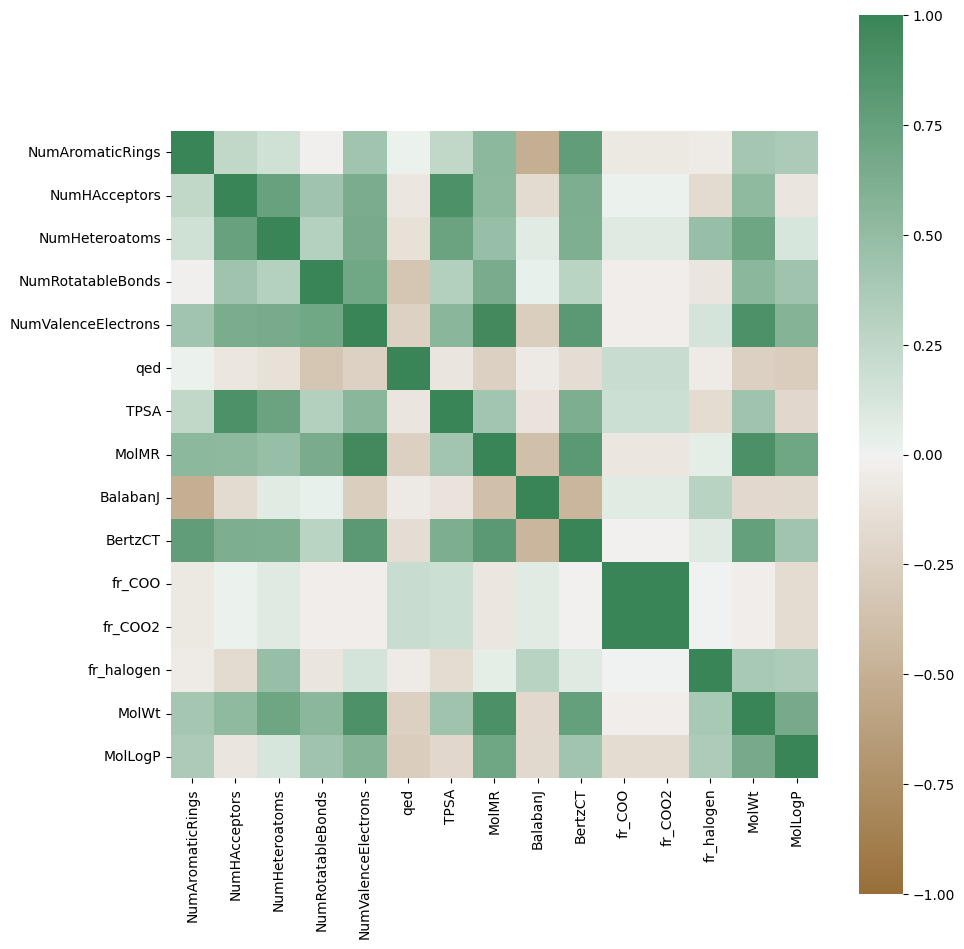

In [19]:
axis_corr = plt.figure(figsize = [10,10])

axis_corr = sns.heatmap(
    corr_moldescr,
    vmin= -1, 
    vmax = 1,
    center=0,
    cmap = sns.diverging_palette(50,500, as_cmap=True),
    square=True,

)
plt.tight_layout()
plt.show()

## Removing correlated descriptors

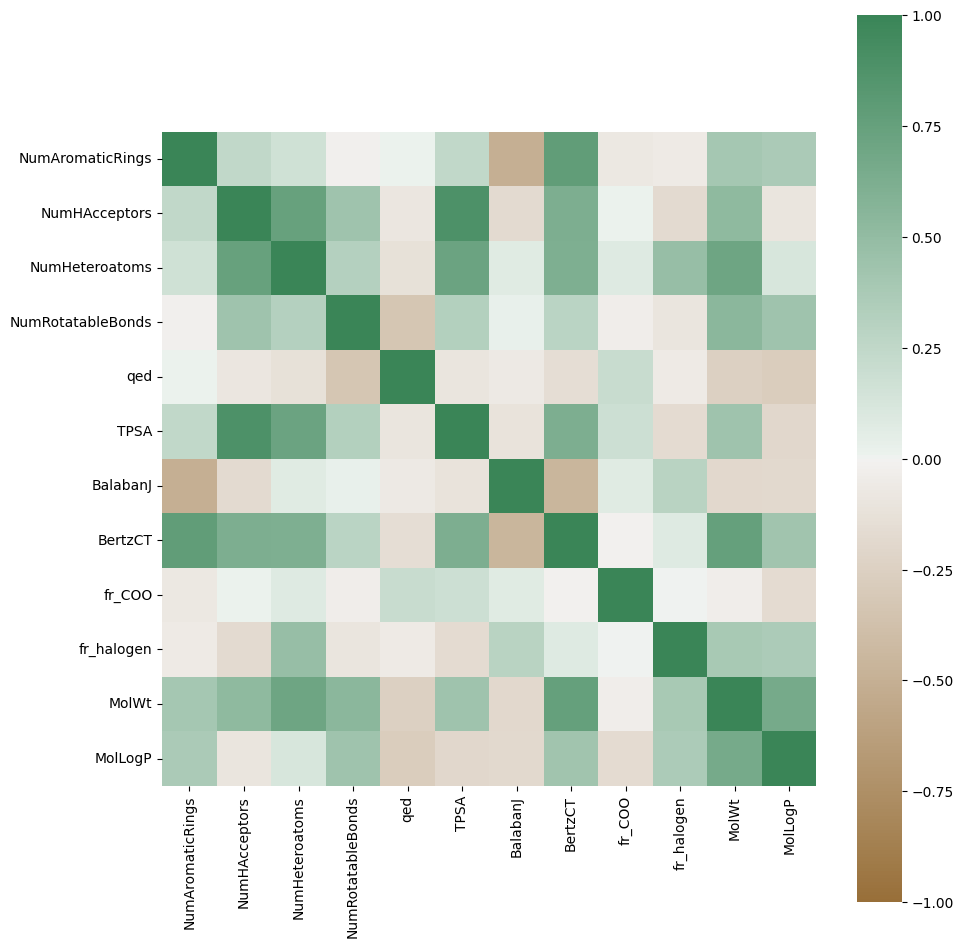

In [20]:
X = X.drop(['NumValenceElectrons', 'MolMR', 'fr_COO2'], axis = 1)
corr_moldescr = X.corr()
corr_moldescr
axis_corr = plt.figure(figsize = [10,10])

axis_corr = sns.heatmap(
    corr_moldescr,
    vmin= -1, 
    vmax = 1,
    center=0,
    cmap = sns.diverging_palette(50,500, as_cmap=True),
    square=True,

)
plt.tight_layout()
plt.show()

In [21]:
X

,NumAromaticRings,NumHAcceptors,NumHeteroatoms,NumRotatableBonds,qed,TPSA,BalabanJ,BertzCT,fr_COO,fr_halogen,MolWt,MolLogP
0,2,0,5,2,0.540334,0.00,2.474117,494.044161,0,5,354.491,6.49550
1,1,1,4,1,0.740184,37.30,3.318913,276.242090,1,2,191.013,2.69160
2,1,1,5,1,0.744344,37.30,3.428931,335.668528,1,3,225.458,3.34500
3,5,0,0,0,0.243454,0.00,2.230840,1069.721887,0,0,252.316,5.73720
4,1,5,7,2,0.548520,106.51,3.267052,375.287402,0,0,184.107,1.20860
...,...,...,...,...,...,...,...,...,...,...,...,...
795,2,4,6,10,0.608597,56.79,1.980197,896.574346,0,1,411.885,3.41040
796,2,3,3,2,0.795366,37.81,2.289333,565.011461,0,0,223.279,2.90002
797,0,0,1,0,0.415670,0.00,2.327883,68.456011,0,0,114.212,1.24670
798,1,4,5,5,0.771792,55.84,3.299967,478.396923,0,0,279.336,1.84434


In [24]:
df_bcf

,Unnamed: 0,CAS,SMILES,Experimental value [log(L/kg)],NumAromaticRings,NumHAcceptors,NumHeteroatoms,NumRotatableBonds,NumValenceElectrons,qed,TPSA,MolMR,BalabanJ,BertzCT,fr_COO,fr_COO2,fr_halogen,MolWt,MolLogP
0,0,50-29-3,c1cc(ccc1C(c2ccc(cc2)Cl)C(Cl)(Cl)Cl)Cl,3.605,2,0,5,2,100,0.540334,0.00,85.0370,2.474117,494.044161,0,0,5,354.491,6.49550
1,1,50-30-6,O=C(O)c1c(cccc1Cl)Cl,-0.222,1,1,4,1,58,0.740184,37.30,43.4213,3.318913,276.242090,1,1,2,191.013,2.69160
2,2,50-31-7,O=C(O)c1c(ccc(c1Cl)Cl)Cl,0.073,1,1,5,1,64,0.744344,37.30,48.4313,3.428931,335.668528,1,1,3,225.458,3.34500
3,3,50-32-8,c1ccc2c(c1)cc3ccc4cccc5ccc2c3c45,2.731,5,0,0,0,92,0.243454,0.00,87.6520,2.230840,1069.721887,0,0,0,252.316,5.73720
4,4,51-28-5,O=[N+]([O-])c1ccc(O)c(c1)[N+](=O)[O-],0.052,1,5,7,2,68,0.548520,106.51,41.4156,3.267052,375.287402,0,0,0,184.107,1.20860
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,795,374726-62-2,O=C(NCCc1ccc(OCC#C)c(OC)c1)C(OCC#C)c2ccc(cc2)Cl,1.681,2,4,6,10,150,0.608597,56.79,113.0137,1.980197,896.574346,0,0,1,411.885,3.41040
796,796,110235-47-7,C(#CC)c1nc(nc(c1)C)Nc2ccccc2,2.447,2,3,3,2,84,0.795366,37.81,69.0457,2.289333,565.011461,0,0,0,223.279,2.90002
797,797,15302-91-7,C[N+]1(C)(CCCCC1),0.301,0,0,1,0,48,0.415670,0.00,35.6934,2.327883,68.456011,0,0,0,114.212,1.24670
798,798,57837-19-1,O=C(OC)C(N(C(=O)COC)c1c(cccc1C)C)C,0.845,1,4,5,5,110,0.771792,55.84,76.7560,3.299967,478.396923,0,0,0,279.336,1.84434


### Target–Descriptor Relationships

In [26]:
corr_target_disc = df_bcf.drop(['Unnamed: 0', 'CAS', 'SMILES', 
                                'NumValenceElectrons', 'MolMR', 'fr_COO2'], 
                                axis=1).corr()
corr_target_disc['Experimental value [log(L/kg)]'].sort_values(ascending=False)

Experimental value [log(L/kg)]    1.000000
MolLogP                           0.575795
fr_halogen                        0.326521
NumAromaticRings                  0.242032
MolWt                             0.187941
BertzCT                           0.113382
qed                               0.011156
NumRotatableBonds                -0.090548
NumHeteroatoms                   -0.126011
BalabanJ                         -0.129652
fr_COO                           -0.272753
NumHAcceptors                    -0.337206
TPSA                             -0.426287
Name: Experimental value [log(L/kg)], dtype: float64

In [13]:
# Nnumber of molecules with QED score less than 0.5
print((df_bcf['qed'] < 0.5).sum())
# Molecule with the maximum molecular weight
max_mw_mol = df_bcf[df_bcf['MolWt'] == df_bcf['MolWt'].max()][['SMILES','MolWt','CAS']]
print(max_mw_mol)
# Print the mean number of valence electrons
print(df_bcf['NumValenceElectrons'].mean())

264
                                                SMILES     MolWt         CAS
766  O([Sn](CC(c1ccccc1)(C)C)(CC(c2ccccc2)(C)C)CC(c...  1052.705  13356-08-6
84.52


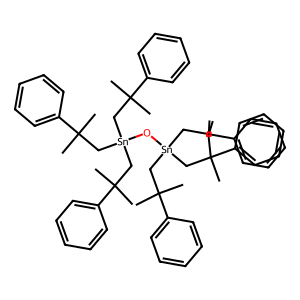

In [14]:
# Plot the molecule with the maximum molecular weight
mol = Chem.MolFromSmiles(max_mw_mol.SMILES.values[0])
Draw.MolToImage(mol)

## BCF Distribution

<Axes: xlabel='Experimental value [log(L/kg)]', ylabel='Count'>

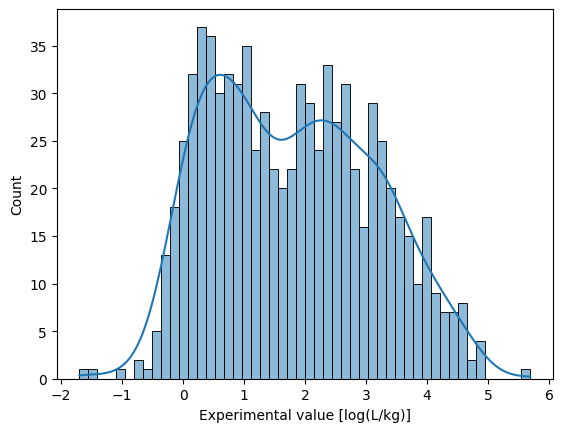

In [48]:
sns.histplot(df_bcf, 
            bins=50,
            kde=True, 
            x = 'Experimental value [log(L/kg)]'
            )

### Conditional Distribution of BCF by Lipophilicity (MolLogP)

#### To investigate the origin of the apparent bimodality in the log-transformed bioconcentration factor (BCF), the target distribution was conditionally analyzed with respect to molecular lipophilicity (MolLogP). MolLogP was chosen because lipophilicity is a primary mechanistic driver of bioaccumulation: compounds with higher lipophilicity tend to partition more readily into lipid-rich biological tissues, resulting in higher BCF values.

#### The dataset was divided into three MolLogP ranges representing low, medium, and high lipophilicity, and the distribution of log(BCF) was examined within each group. The resulting plot shows a clear separation of BCF regimes. Compounds with low MolLogP values predominantly occupy the low-BCF region, while compounds with moderate to high MolLogP values correspond to substantially higher BCF values. The two modes observed in the overall target distribution align closely with these lipophilicity-based groups.

#### This result indicates that the apparent bimodality in log(BCF) is not an artifact of noise or measurement error but reflects chemically meaningful sub-populations governed primarily by lipophilicity. Consequently, the relationship between molecular descriptors and BCF is likely regime-dependent, suggesting that models which can capture non-linear or piecewise behavior (e.g., tree-based or rule-based models) may be more appropriate than a single global linear model.

<Axes: xlabel='Experimental value [log(L/kg)]', ylabel='Count'>

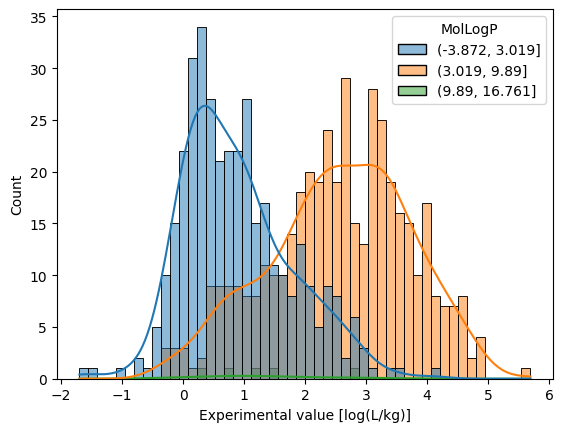

In [95]:
sns.histplot(df_bcf, 
            bins=50,
            kde=True, 
            x = 'Experimental value [log(L/kg)]',
            hue=pd.cut(df_bcf["MolLogP"], bins=3),
            )

### Gaussian Mixture Model Analysis of log(BCF)

### As an exploratory analysis, a Gaussian Mixture Model (GMM) with two components was fitted to assess whether the apparent bimodality in the log-transformed bioconcentration factor reflects distinct latent regimes. The resulting component labels primarily separate the data along the log(BCF) axis, with substantial overlap across the MolLogP range. This indicates that the GMM is identifying low-BCF and high-BCF outcome regimes rather than well-separated chemical clusters.

### The strong overlap in MolLogP between the two components suggests that lipophilicity alone does not define a sharp boundary between regimes. Instead, MolLogP appears to constrain the feasible range of BCF values, while additional molecular descriptors likely govern the transition between low- and high-BCF outcomes. These results support a continuous, regime-dependent relationship between molecular properties and BCF and motivate the use of non-linear or regime-aware regression models rather than hard clustering approaches.

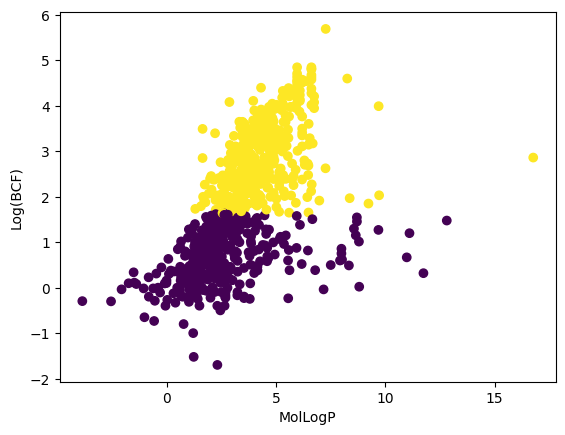

In [40]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(df_bcf[['Experimental value [log(L/kg)]']])

gmm_labels = gmm.predict(df_bcf[['Experimental value [log(L/kg)]']])

plt.scatter(df_bcf["MolLogP"], df_bcf["Experimental value [log(L/kg)]"], c = gmm_labels)
plt.xlabel('MolLogP')
plt.ylabel('Log(BCF)')
plt.show()

In [37]:
from sklearn.decomposition import PCA

y_true = df_bcf['Experimental value [log(L/kg)]'].to_numpy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

pca.explained_variance_ratio_

array([0.36437895, 0.16795217, 0.15215833, 0.11202946, 0.07678762,
       0.05615366, 0.03842347, 0.01231571, 0.00745274, 0.00705265,
       0.00389031, 0.00140494])

In [38]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=[f"PC{i+1}" for i in range(len(X.columns))]
)
loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
NumAromaticRings,0.264272,0.091429,-0.488539,0.205616,-0.068779,-0.184509,0.520469,0.393037,-0.208609,0.043025,-0.359606,0.045027
NumHAcceptors,0.375692,-0.370839,0.074503,-0.128881,-0.122531,0.138076,-0.055343,-0.074017,-0.544258,-0.416172,0.010276,-0.432472
NumHeteroatoms,0.382889,-0.106744,0.337621,0.227352,-0.189521,0.032687,-0.142046,0.121835,-0.070484,-0.192586,-0.015666,0.749676
NumRotatableBonds,0.257532,0.091210,0.196756,-0.494341,0.418280,0.349690,0.065045,0.559845,0.083533,0.121682,0.074612,-0.004730
qed,-0.126916,-0.233083,-0.165102,0.497147,0.140091,0.782376,0.119984,-0.031172,0.087497,0.008598,0.017052,-0.004887
TPSA,0.351475,-0.434200,0.093902,-0.037258,-0.064407,-0.097736,0.050276,-0.111508,0.673127,0.040831,-0.397158,-0.191222
BalabanJ,-0.146142,0.006715,0.585093,0.008097,-0.061316,-0.012811,0.769068,-0.173512,-0.058329,0.016999,0.077825,-0.030873
BertzCT,0.433928,0.018379,-0.227824,0.128746,-0.039938,-0.118884,0.164841,-0.075468,0.227008,0.049937,0.797438,-0.066029
fr_COO,-0.006947,-0.249322,0.120173,0.351382,0.790042,-0.393498,-0.047601,0.001319,-0.122703,-0.056494,0.015579,-0.010710
fr_halogen,0.076085,0.379614,0.379717,0.501554,-0.187472,-0.043487,-0.218619,0.392490,0.096955,-0.013123,-0.020494,-0.453311


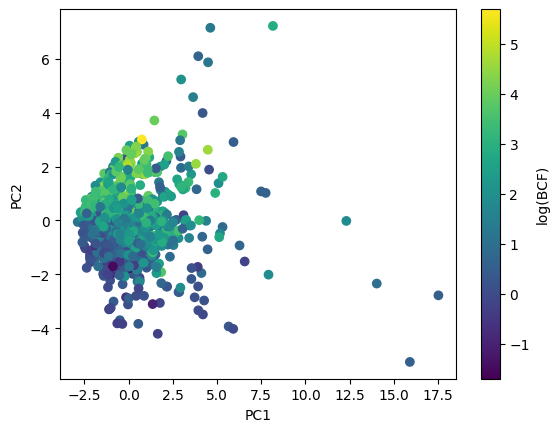

In [44]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_true, cmap="viridis")
plt.colorbar(label="log(BCF)")  
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

## KNN for regression (baseline)

### Train and Test split 80/20

In [147]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y_true, test_size=0.2, random_state=42)

In [148]:
# Print the number of points in the training and test sets
print('Training points: ', len(y_train))
print('Test points: ', len(y_test))

Training points:  640
Test points:  160


### Standardization

In [149]:
# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Training KNN Regression model with k = 5

In [155]:
knn_regr = KNeighborsRegressor(n_neighbors=5,
                               weights='distance',
                            )
knn_regr.fit(X_train, y_train)

,n_neighbors,5
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### Make prediction

In [156]:
y_pred = knn_regr.predict(X_test)
y_pred_train = knn_regr.predict(X_train)

### Evaluate model

In [157]:
rmse_test = np.sqrt(mean_absolute_error(y_test, y_pred))
rmse_train = np.sqrt(mean_absolute_error(y_train, y_pred_train))
r2_test = r2_score(y_test, y_pred)
r2_train = r2_score(y_train, y_pred_train)

print(f'Mean Squared Error Test: {rmse_test}')
print(f'Mean Squared Error Train: {rmse_train}')
print(f'R-Squared Test: {r2_test}')
print(f'R-Squared Train: {r2_train}')

Mean Squared Error Test: 0.8101831105724968
Mean Squared Error Train: 0.07168725479469834
R-Squared Test: 0.5651628555562638
R-Squared Train: 0.9988794535964974


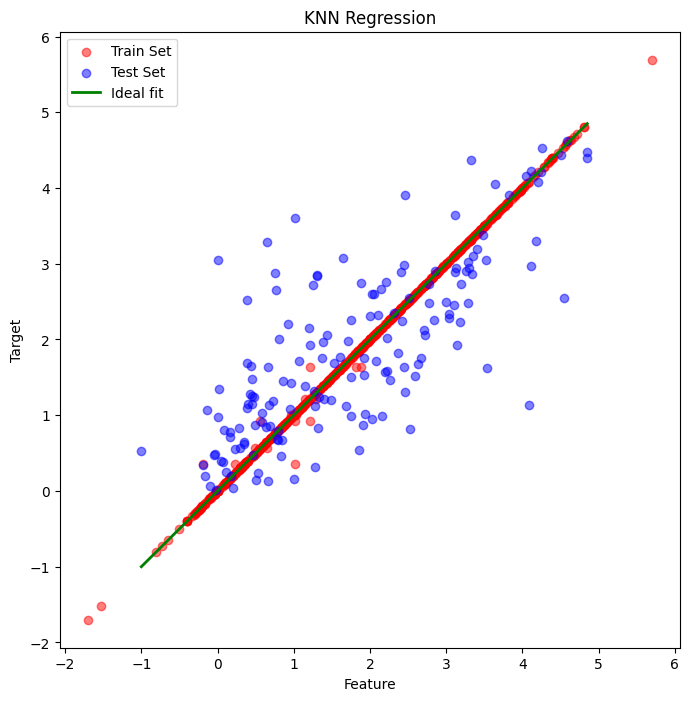

In [158]:
plt.figure(figsize=(8,8))
plt.scatter(y_train, y_pred_train, color='red', label='Train Set', alpha = 0.5)
plt.scatter(y_test, y_pred, color='blue', label='Test Set', alpha = 0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='green', linewidth=2, label='Ideal fit')
plt.title('KNN Regression')
plt.xlabel('Feature')
plt.ylabel('Target')
plt.legend()
plt.show()

# Finding the best k in kNN using K-Fold Cross Validation

In [160]:
from sklearn.model_selection import cross_validate

num_ks = np.arange(1, 50, 1).astype(int)

train_rmse = []
valid_rmse = []

for i in tqdm(range(len(num_ks))):
  knn = KNeighborsRegressor(n_neighbors=num_ks[i])
  cv_dict = cross_validate(knn, X_train, y_train, cv=10, scoring='r2', return_train_score=True)
  k_fold_train_score = cv_dict['train_score']
  k_fold_valid_score = cv_dict['test_score']

  train_rmse.append(k_fold_train_score.mean())
  valid_rmse.append(k_fold_valid_score.mean())

100%|██████████| 49/49 [00:10<00:00,  4.83it/s]


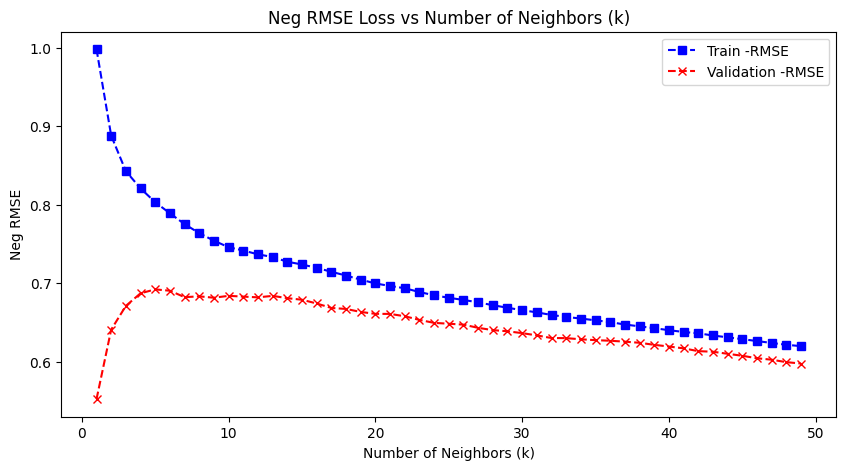

In [161]:
plt.figure(figsize=(10, 5))
plt.plot(num_ks, train_rmse, 'bs--', label='Train -RMSE')
plt.plot(num_ks, valid_rmse, 'rx--', label='Validation -RMSE')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Neg RMSE')
plt.title('Neg RMSE Loss vs Number of Neighbors (k)')
plt.legend()
plt.show()

In [163]:
print(f"Best k: {num_ks[np.argmin(valid_rmse)]}")

Best k: 1
